In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import math
from typing import Optional, Tuple, List, Union, Dict, Any


In [28]:

# set seed
import random
torch.manual_seed(42)

t = torch.randint(0, 10, (2, 4, 6))

# tensor([[[2, 7, 6, 4, 6, 5],
#          [0, 4, 0, 3, 8, 4],
#          [0, 4, 1, 2, 5, 5],
#          [7, 6, 9, 6, 3, 1]],

#         [[9, 3, 1, 9, 7, 9],
#          [2, 0, 5, 9, 3, 4],
#          [9, 6, 2, 0, 6, 2],
#          [7, 9, 7, 3, 3, 4]]])

print(t)

repeat_num = 4
t_expand = t.unsqueeze(2).expand(-1, -1, repeat_num, -1).contiguous().view(t.shape[0], -1, t.shape[-1])
t_cat = torch.cat([t for _ in range(repeat_num)], dim=1)
t_stack = torch.stack([t for _ in range(repeat_num)], dim=1).view(2, -1, 8)
t_repeat = t.repeat_interleave(repeat_num, dim=1)
index = torch.tensor([[0, 1, 0, 1], [0, 1, 1, 1]]).unsqueeze(-1)
t_gather = torch.gather(t, dim=0, index=index) # 根据index从t中选择元素
t_select = torch.select(t, dim=1, index=3) # 根据index从t中选择元素
t_roll = torch.roll(t, 1, -1) # 将t的最后一维向右移动1位
t_where_other = torch.where(t_roll > 5, t, torch.zeros_like(t_roll)) # 将t_roll中大于5的值替换为t中对应的值，否则替换为0

# 输入：1个批量、1个通道、3×3的张量（NCHW）
x = torch.tensor([[[[1,2,3], [4,5,6], [7,8,9]], [[1,2,3], [4,5,6], [7,8,9]]]])  # shape: (1,2,3,3)

# 填充：宽度左右各1，高度上下各2，用0填充（constant模式）
x_pad = F.pad(x, pad=(0, 0), mode='constant', value=0)

print(x_pad)
# 输出shape：(1,1, 3+2+2, 3+1+1) = (1,1,7,5)

print(t.shape)
print("Stack Values:\n")
print(t_expand.shape)
print(t_cat.shape)
print(t_stack.shape)
print(t_repeat.shape)

print(t_roll)
print(t_select)
print(t_select.diff(1))
print(t_select.clamp(0, 3))

# print(gather_index)


tensor([[[2, 7, 6, 4, 6, 5],
         [0, 4, 0, 3, 8, 4],
         [0, 4, 1, 2, 5, 5],
         [7, 6, 9, 6, 3, 1]],

        [[9, 3, 1, 9, 7, 9],
         [2, 0, 5, 9, 3, 4],
         [9, 6, 2, 0, 6, 2],
         [7, 9, 7, 3, 3, 4]]])
tensor([[[[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]],

         [[1, 2, 3],
          [4, 5, 6],
          [7, 8, 9]]]])
torch.Size([2, 4, 6])
Stack Values:

torch.Size([2, 16, 6])
torch.Size([2, 16, 6])
torch.Size([2, 12, 8])
torch.Size([2, 16, 6])
tensor([[[5, 2, 7, 6, 4, 6],
         [4, 0, 4, 0, 3, 8],
         [5, 0, 4, 1, 2, 5],
         [1, 7, 6, 9, 6, 3]],

        [[9, 9, 3, 1, 9, 7],
         [4, 2, 0, 5, 9, 3],
         [2, 9, 6, 2, 0, 6],
         [4, 7, 9, 7, 3, 3]]])
tensor([[7, 6, 9, 6, 3, 1],
        [7, 9, 7, 3, 3, 4]])
tensor([[-1,  3, -3, -3, -2],
        [ 2, -2, -4,  0,  1]])
tensor([[3, 3, 3, 3, 3, 1],
        [3, 3, 3, 3, 3, 3]])


In [20]:
import abc
import torch

class ND(abc.ABC):
    def __init__(self, *args):
        self.shape = args
        self.max_val = 100
        self.rand_points = self._get_rand_points(self.shape)
    
    def __len__(self):
        return len(self.shape)
    
    def __getitem__(self, index: int) -> torch.Tensor:
        return self.rand_points[index]
    
    @classmethod
    def create_from_shape(cls, shape: tuple[int, ...]) -> "ND":
        return cls(*shape)
    
    @staticmethod
    def _get_numel(inputs: torch.Tensor) -> int:
        return inputs.numel()
    
    @abc.abstractmethod
    def _get_rand_points(self, shape: tuple[int, ...]) -> torch.Tensor:
        """子类必须实现此方法来生成随机点"""
        pass

class littleND(ND):
    def _get_rand_points(self, shape: tuple[int, ...]) -> torch.Tensor:
        return torch.randint(0, self.max_val, shape)

if __name__ == "__main__":
    lnd = littleND.create_from_shape((1000, 100, 100))
    print(lnd.shape)
    print(lnd.rand_points.shape)
    print(lnd.rand_points)



(1000, 100, 100)
torch.Size([1000, 100, 100])
tensor([[[93, 77, 70,  ..., 82, 70, 18],
         [68,  7, 22,  ..., 25,  8,  4],
         [72, 98, 13,  ..., 42, 54, 11],
         ...,
         [45, 98,  7,  ...,  2, 14, 55],
         [52, 84, 54,  ..., 40, 88, 65],
         [63, 97, 53,  ..., 46,  5, 85]],

        [[31, 73, 99,  ..., 78,  9, 51],
         [63, 92, 79,  ...,  4, 31,  1],
         [92, 15, 56,  ..., 85, 68, 35],
         ...,
         [ 1, 11, 88,  ..., 12, 44, 12],
         [65, 62, 78,  ..., 10, 66, 76],
         [12, 58, 23,  ..., 71, 87, 18]],

        [[37, 58,  6,  ..., 21, 65, 39],
         [ 9, 22, 78,  ..., 21, 35, 54],
         [ 6, 26, 72,  ..., 88, 69, 21],
         ...,
         [96, 63, 10,  ..., 30, 19, 54],
         [93, 43, 40,  ..., 43, 35, 89],
         [77, 63, 29,  ..., 57, 29, 85]],

        ...,

        [[87, 27, 11,  ..., 93,  3, 30],
         [95, 37, 41,  ..., 33,  8, 47],
         [56, 97, 24,  ..., 10, 34,  6],
         ...,
         [94,  3,

In [ ]:
from collections import Counter, defaultdict


rand_points = torch.randint(0, 100, (1000, 100, 100))

clusters = defaultdict(list[int])





In [ ]:

seq_len = 4
scores = torch.randn((2, 2, 4, 4))

mask = torch.triu(
    torch.full((seq_len, seq_len), float("-inf"), device=scores.device),
    diagonal=1
).unsqueeze(0).unsqueeze(0)

print(scores.shape)  # scores+mask
print(mask.shape)

scores = scores + mask  # scores+mask

print(scores)
    

torch.Size([2, 2, 4, 4])
torch.Size([1, 1, 4, 4])
tensor([[[[ 0.1026,    -inf,    -inf,    -inf],
          [-0.1536, -0.6768,    -inf,    -inf],
          [-0.2093, -0.0372, -0.4675,    -inf],
          [ 0.1713,  0.0106, -0.4671, -0.1442]],

         [[-0.3031,    -inf,    -inf,    -inf],
          [-3.8981, -3.2122,    -inf,    -inf],
          [-0.7364,  0.9243,  2.3079,    -inf],
          [ 0.4285, -0.6980,  0.7977, -0.6847]]],


        [[[-0.0271,    -inf,    -inf,    -inf],
          [ 0.1937,  1.1010,    -inf,    -inf],
          [-1.4737, -0.8979, -1.0088,    -inf],
          [-0.0044, -1.5025, -0.0712,  0.9473]],

         [[ 0.5390,    -inf,    -inf,    -inf],
          [ 0.4459,  0.4233,    -inf,    -inf],
          [-0.6480, -1.2644,  1.1294,    -inf],
          [ 0.0288,  1.2363,  0.8746,  2.0497]]]])


In [ ]:
inputs = torch.randn((10, 10))
rate = 0.9
## drop1 
# droped_inputs = torch.where(torch.rand(inputs.shape) < rate, inputs, torch.zeros_like(inputs))
## drop2
inputs = inputs * (torch.rand(inputs.shape) > rate) * (1 / (1 - rate))


print(inputs)



tensor([[ 0.0000, -9.6596,  0.0000, -0.0000, -0.0000,  0.0000, -0.0000, -0.0000,
          0.0000,  0.0000],
        [ 0.0000, -0.0000, -0.0000, -0.0000, -4.4746, -0.0000, -0.0000,  0.0000,
         -0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.0000,  0.0000,  0.0000,  0.0000, 16.2077,  0.0000,
         -0.0000, -0.0000],
        [ 0.0000, -0.0000, -0.0000, -0.0000, -0.0000, -0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000, -0.0000,  0.0000,  0.0000,  0.0000, -0.0000, -0.0000,
          0.0000, -0.0000],
        [-0.0000, -3.7266,  0.0000,  0.0000,  0.0000,  1.5175,  0.0000,  0.0000,
          0.0000, -0.0000],
        [-0.0000, -0.0000, -0.0000, -3.1552,  0.0000,  0.0000,  0.0000, -0.0000,
         -0.0000,  0.0000],
        [-0.0000, -0.0000,  0.0000,  0.0000, -0.0000, -0.0000, -0.0000, -0.0000,
          0.0000, -0.0000],
        [ 0.0000,  0.0000, -0.0000,  0.0000, -0.0000, -0.0000, -0.0000,  0.0000,
          2.6270, -0.0000],
        [ 0.0000, -

In [25]:
import torch

# 固定随机种子，确保结果可复现
torch.manual_seed(42)

# 生成输入张量：shape=(2, 4)，值在[0,10)之间的整数
input_ids = torch.randint(0, 10, (2, 4))
print("input_ids（输入张量）:\n", input_ids, "\n")

# 定义scores张量：shape与input_ids一致(2,4)，模拟模型输出的分数
scores = torch.randn(2, 4)  # 用标准正态分布生成随机分数
print("scores（分数张量）:\n", scores, "\n")

# 执行topk：提取每个样本的前2个最大值及其索引
top_val, top_idx = torch.topk(scores, k=2, dim=0, sorted=False)

# 打印结果及形状
print("top_val（提取的前2个最大值）:\n", top_val)
print("top_val.shape:", top_val.shape, "\n")
print("top_idx（最大值对应的索引）:\n", top_idx)
print("top_idx.shape:", top_idx.shape)


# argmax
print("argmax 结果:\n", torch.argmax(scores, dim=-1), "\n")
print("argmax 结果的形状:", torch.argmax(scores, dim=-1).shape, "\n")
print("argmax 结果的形状:", torch.argmax(scores, dim=-1).unsqueeze(-1), "\n")


input_ids（输入张量）:
 tensor([[2, 7, 6, 4],
        [6, 5, 0, 4]]) 

scores（分数张量）:
 tensor([[-1.1229, -0.1863,  2.2082, -0.6380],
        [ 0.4617,  0.2674,  0.5349,  0.8094]]) 

top_val（提取的前2个最大值）:
 tensor([[ 0.4617,  0.2674,  2.2082,  0.8094],
        [-1.1229, -0.1863,  0.5349, -0.6380]])
top_val.shape: torch.Size([2, 4]) 

top_idx（最大值对应的索引）:
 tensor([[1, 1, 0, 1],
        [0, 0, 1, 0]])
top_idx.shape: torch.Size([2, 4])
argmax 结果:
 tensor([2, 3]) 

argmax 结果的形状: torch.Size([2]) 

argmax 结果的形状: tensor([[2],
        [3]]) 



In [9]:
rope_base = 1e6
dim=768
orig_max=2048

freqs = 1.0 / (rope_base ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim))
corr_dim = next((i for i in range(dim // 2) if 2 * math.pi / freqs[i] > orig_max), dim // 2)

print(freqs.shape)
print(freqs[100])

print(corr_dim.shape)


torch.Size([384])
tensor(0.0274)


AttributeError: 'int' object has no attribute 'shape'

In [ ]:

def softmax(inputs: torch.Tensor, dim: int) -> torch.Tensor:
    max_val = torch.max(inputs, dim=dim, keepdim=True)
    exp_inputs = torch.exp(inputs - max_val)
    sum_exp = torch.sum(exp_inputs, dim=dim, keepdim=True)
    return exp_inputs / sum_exp


random_inputs = torch.randn((4, 8, 16))

probs = torch.softmax(random_inputs, dim=-1)

print(probs.shape)
print(torch.sum(probs, dim=-1, keepdim=True).shape)
print(torch.sum(probs, dim=-1, keepdim=False).shape)

torch.Size([4, 8, 16])
torch.Size([4, 8, 1])
torch.Size([4, 8])


In [39]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def demo_func(x):
    return x * 2

with ThreadPoolExecutor(max_workers=4) as executor:
    results = list(executor.map(demo_func, range(10)))
    # results = [executor.submit(demo_func, i) for i in range(10)]
    # results = [future.result() for future in concurrent.futures.as_completed(results)]
    # results = [future.result() for future in results]
    # results = [future.result() for future in as_completed(results)]

    print(results)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [41]:
input = torch.tensor([[1,2,3,4],
                      [5,6,7,8],
                      [9,10,11,12]])  # shape (3,4)

index = torch.tensor([[0,1,2,0],  # 第0列：取第0行（1）；第1列：取第1行（6）；...
                      [2,0,1,2]]) # 第0列：取第2行（9）；第1列：取第0行（2）；...

result = input.gather(0, index)
print(result)
# result shape (2,4)，值为：[[1,6,11,4], [9,2,7,12]]

tensor([[ 1,  6, 11,  4],
        [ 9,  2,  7, 12]])


In [2]:
import torch
import torch.nn.functional as F

# --- 1. 定义我们改进后的手动模型 (增加了 Bias) ---
class ManualSwiGLU_Refined:
    def __init__(self, input_dim, hidden_dim, output_dim):
        # 初始化权重
        scale = (1.0 / input_dim) ** 0.5
        scale_out = (1.0 / hidden_dim) ** 0.5
        
        # 权重 W
        self.W_g = torch.randn(input_dim, hidden_dim) * scale
        self.W_u = torch.randn(input_dim, hidden_dim) * scale
        self.W_d = torch.randn(hidden_dim, output_dim) * scale_out
        
        # 偏置 Bias (新增) - 初始化为 0
        self.b_g = torch.zeros(hidden_dim)
        self.b_u = torch.zeros(hidden_dim)
        self.b_d = torch.zeros(output_dim)
        
        # 缓存
        self.cache = {}

    def forward(self, x):
        # 1. Linear: XW + b
        z_g = x @ self.W_g + self.b_g
        z_u = x @ self.W_u + self.b_u
        
        # 2. Activation: SiLU
        # 使用 PyTorch 的 sigmoid 保证数值稳定性, 但逻辑依然手动
        sig_z_g = torch.sigmoid(z_g)
        a_g = z_g * sig_z_g
        
        # 3. Interaction
        h = a_g * z_u
        
        # 4. Output
        y_pred = h @ self.W_d + self.b_d
        
        self.cache = {'x': x, 'z_u': z_u, 'a_g': a_g, 'sig_z_g': sig_z_g, 'h': h}
        return y_pred

    def backward(self, dy):
        """
        dy: dL/dY_pred (N, out)
        """
        x = self.cache['x']
        z_u = self.cache['z_u']
        a_g = self.cache['a_g']
        sig_z_g = self.cache['sig_z_g']
        N = x.shape[0]

        # --- Layer 3: Down Proj ---
        # W_d 梯度
        grad_W_d = self.cache['h'].T @ dy
        # Bias_d 梯度: 在 Batch 维度求和
        grad_b_d = torch.sum(dy, dim=0)
        
        # 回传误差到 H
        d_h = dy @ self.W_d.T
        
        # --- Interaction Layer ---
        # d_h 拆分给 z_u 和 a_g
        d_z_u = d_h * a_g
        d_a_g = d_h * z_u
        
        # --- Layer 2: Up Proj ---
        grad_W_u = x.T @ d_z_u
        grad_b_u = torch.sum(d_z_u, dim=0)
        
        # --- Layer 1: Gate Proj (SiLU Derivative) ---
        # SiLU'(x) = sigma(x) + SiLU(x)*(1-sigma(x))
        # 这里的 a_g 就是 SiLU(z_g)
        silu_prime = sig_z_g + a_g * (1.0 - sig_z_g)
        d_z_g = d_a_g * silu_prime
        
        grad_W_g = x.T @ d_z_g
        grad_b_g = torch.sum(d_z_g, dim=0)
        
        return {
            'W_g': grad_W_g, 'b_g': grad_b_g,
            'W_u': grad_W_u, 'b_u': grad_b_u,
            'W_d': grad_W_d, 'b_d': grad_b_d
        }

# --- 2. 验证脚本 ---

def verify_gradients():
    print("正在进行梯度对拍验证...")
    
    # 设置参数
    N, D_in, D_h, D_out = 5, 10, 20, 1
    x_input = torch.randn(N, D_in)
    y_target = torch.randn(N, D_out)
    
    # 实例化手动模型
    manual_model = ManualSwiGLU_Refined(D_in, D_h, D_out)
    
    # --- 准备自动求导的 Tensor ---
    # 我们深拷贝手动模型的权重，并开启 requires_grad
    # 这样可以确保两者起点完全一致
    w_g_auto = manual_model.W_g.clone().detach().requires_grad_(True)
    b_g_auto = manual_model.b_g.clone().detach().requires_grad_(True)
    w_u_auto = manual_model.W_u.clone().detach().requires_grad_(True)
    b_u_auto = manual_model.b_u.clone().detach().requires_grad_(True)
    w_d_auto = manual_model.W_d.clone().detach().requires_grad_(True)
    b_d_auto = manual_model.b_d.clone().detach().requires_grad_(True)
    
    # ==========================
    # 1. 运行自动求导 (PyTorch Autograd)
    # ==========================
    # 前向
    z_g = x_input @ w_g_auto + b_g_auto
    z_u = x_input @ w_u_auto + b_u_auto
    # F.silu 是官方实现
    h = F.silu(z_g) * z_u
    y_auto = h @ w_d_auto + b_d_auto
    
    # Loss
    loss_auto = 0.5 * F.mse_loss(y_auto, y_target, reduction='sum') / N * 2 
    # 注意: F.mse_loss 默认是 mean。
    # 你的手动 Loss 是 mean((y-t)^2)。导数是 2/N * (y-t)。
    # 为了对齐，我们这里直接用 sum loss 然后手动模拟 mean
    loss_auto = torch.mean((y_auto - y_target)**2)
    
    # 反向
    loss_auto.backward()
    
    # ==========================
    # 2. 运行手动求导 (Manual)
    # ==========================
    y_manual = manual_model.forward(x_input)
    loss_manual = torch.mean((y_manual - y_target)**2)
    
    # 计算 dL/dY
    # MSE Derivative: 2/N * (y_pred - y_target)
    dy = 2.0 * (y_manual - y_target) / N
    
    grads_manual = manual_model.backward(dy)
    
    # ==========================
    # 3. 对比结果
    # ==========================
    
    print(f"Loss 对比: Auto={loss_auto.item():.6f}, Manual={loss_manual.item():.6f}")
    
    # 定义对比函数
    def check(name, g_manual, g_auto):
        diff = (g_manual - g_auto).abs().max()
        if diff < 1e-5:
            print(f"[✅ 通过] {name} 梯度最大误差: {diff:.8f}")
        else:
            print(f"[❌ 失败] {name} 梯度最大误差: {diff:.8f}")
            
    print("-" * 30)
    check("W_g", grads_manual['W_g'], w_g_auto.grad)
    check("b_g", grads_manual['b_g'], b_g_auto.grad)
    check("W_u", grads_manual['W_u'], w_u_auto.grad)
    check("b_u", grads_manual['b_u'], b_u_auto.grad)
    check("W_d", grads_manual['W_d'], w_d_auto.grad)
    check("b_d", grads_manual['b_d'], b_d_auto.grad)

if __name__ == "__main__":
    verify_gradients()

正在进行梯度对拍验证...
Loss 对比: Auto=0.824530, Manual=0.824530
------------------------------
[✅ 通过] W_g 梯度最大误差: 0.00000003
[✅ 通过] b_g 梯度最大误差: 0.00000003
[✅ 通过] W_u 梯度最大误差: 0.00000003
[✅ 通过] b_u 梯度最大误差: 0.00000001
[✅ 通过] W_d 梯度最大误差: 0.00000012
[✅ 通过] b_d 梯度最大误差: 0.00000000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch.optim as optim
from transformers import AutoModelForCausalLM, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def get_log_probs(inputs, model, tokenizer):
    with torch.no_grad():
        input_ids = tokenizer(inputs, return_tensors="pt").to(device)
        logprobs = torch.log_softmax(model(input_ids).logits, dim=-1)
        return logprobs


def test_ag0(model, ref_model, input_datas, tokenizer, beta=0.1):
    for input_data_batch in input_datas:
        input_x = input_data_batch["input"]
        input_y_accept = input_data_batch["output_accept"]
        input_y_reject = input_data_batch["output_reject"]

        input_accepts = input_x + input_y_accept
        input_rejects = input_x + input_y_reject
        inputs = torch.cat([input_accepts, input_rejects], dim=0)
        
        policy_log_probs = get_log_probs(inputs, model, tokenizer)
        policy_log_probs_accept = policy_log_probs[:len(input_accepts)]
        policy_log_probs_reject = policy_log_probs[len(input_accepts):]

        ref_log_probs = get_log_probs(inputs, ref_model, tokenizer)
        ref_log_probs_accept = ref_log_probs[:len(input_accepts)]
        ref_log_probs_reject = ref_log_probs[len(input_accepts):]

        ratios_accept = policy_log_probs_accept - ref_log_probs_accept
        ratios_reject = policy_log_probs_reject - ref_log_probs_reject

        loss = -torch.mean(torch.log(torch.sigmoid(beta * (ratios_accept - ratios_reject))))
        print(loss)






False


### DDP

In [ ]:
import os
import torch
import torch.distributed as dist
from torch.utils.data import DataLoader, DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP

# 1. 获取环境变量（多机多卡下由 torchrun 自动注入）
rank = int(os.environ.get("RANK", 0))
world_size = int(os.environ.get("WORLD_SIZE", 1))
local_rank = int(os.environ.get("LOCAL_RANK", 0))  # 节点内GPU编号，用于指定设备

# 2. 设置当前进程的GPU（必须用 local_rank，因为每个节点的GPU编号都是0~N-1）
torch.cuda.set_device(local_rank)
device = torch.device("cuda", local_rank)

# 3. 初始化分布式进程组（多机多卡核心：跨机器通信）
if world_size > 1:
    dist.init_process_group(
        backend="nccl",  # GPU训练必用NCCL后端（支持跨机器通信）
        init_method="env://",  # 从环境变量读取主节点IP、端口等信息（torchrun自动注入）
        world_size=world_size,
        rank=rank
    )

# 4. 定义模型、数据集（所有节点代码一致）
model = YourModel().to(device)
# 包装DDP模型（多机多卡分布式训练核心：梯度同步）
if world_size > 1:
    model = DDP(model, device_ids=[local_rank], output_device=local_rank)

train_dataset = YourDataset(...)  # 所有节点的数据集必须一致

# 5. 数据分片（DistributedSampler自动按全局rank分片，确保多机数据不重复）
train_sampler = DistributedSampler(
    train_dataset,
    world_size=world_size,
    rank=rank,
    shuffle=True  # 多机下shuffle需通过sampler实现，避免各节点数据顺序一致
) if world_size > 1 else None

train_loader = DataLoader(
    train_dataset,
    batch_size=32,  # 单卡batch_size（总batch_size = 单卡batch_size * world_size）
    sampler=train_sampler,  # 多机多卡必须用DistributedSampler
    shuffle=(train_sampler is None),  # 单机时才手动shuffle
    num_workers=4
)

# 6. 训练逻辑（仅主节点保存模型、打印日志）
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
for epoch in range(100):
    # 多机下需更新sampler的epoch（确保shuffle在不同epoch一致）
    if train_sampler is not None:
        train_sampler.set_epoch(epoch)
    
    model.train()
    for batch in train_loader:
        batch = batch.to(device)
        output = model(batch)
        loss = loss_fn(output, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # 仅主节点（rank=0）执行保存、日志操作（避免多节点重复）
    if rank == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")
        torch.save(model.module.state_dict(), f"model_epoch_{epoch}.pth")  # DDP模型需取.module

# 7. 清理分布式进程组（可选，程序结束会自动清理）
if world_size > 1:
    dist.destroy_process_group()

In [4]:
from collections import Counter, defaultdict


n = [1,2,4,2,4,6,77,4,2,3,2,25]

print(sorted(list(Counter(n).items()), key=lambda x: x[0], reverse=True))



[(77, 1), (25, 1), (6, 1), (4, 3), (3, 1), (2, 4), (1, 1)]


In [ ]:
intervene_prompt = """You are a **Socratic Reasoning Supervisor** and **Logic Auditor** for a large language model.
Your goal is to monitor the student's (model's) reasoning process step-by-step.

**Your Workflow:**
1.  **Analyze**: Read the provided `Question` and the student's `Current Reasoning Trace`.
2.  **Diagnose (System 2 Thought)**:
    - Generate a `<think>` block.
    - Inside, perform a **Shadow Verification**:
        - If the step involves calculation, re-calculate it independently.
        - If the step involves logic, verify the rule application.
        - If you detect a pattern of error (e.g., hallucination, logic gap), diagnose it.
3.  **Act**:
    - If the reasoning is sound: Output `<GO>`.
    - If there is a critical error or high-risk pattern: Output `<WAIT>` followed by a brief, fuzzy guidance (imperative mood, do not leak answer).

**Output Format:**
<think>
[Target]: ...
[Analysis/Calculation]: ...
[Verdict]: ...
</think>

<GO> or <WAIT> [Guidance]

**Question & Student Response:**
"""

system_prompt="You are an expert reasoner with extensive experience in all areas. You approach problems through systematic thinking and rigorous reasoning. Your response should reflect deep understanding and precise logical thinking, making your solution path and reasoning clear to others. Please put your thinking process within <think>...</think> tags."



def format_cold_start_train(messages, internal_thought):
    for msg in messages:
        if msg["role"] == "user":
            msg["content"] = intervene_prompt + msg["content"].replace("\n\n<think>", "Student Response: ")
        elif msg["role"] == "assistant":
            msg["content"] = internal_thought + "\n\n" + msg["content"]
    messages.insert(0, {
        "role": "system",
        "content": system_prompt
    })
    return messages

import json
with open("/mnt/shared-storage-user/liuhongwei/main_works/show.json", "r") as f:
    for line in f:
        item = json.loads(line)
        print(json.dumps(format_cold_start_train(item["messages"], item["internal_thought"]), ensure_ascii=False, indent=4))
        break




[
    {
        "role": "user",
        "content": "You are a **Socratic Reasoning Supervisor** and **Logic Auditor** for a large language model.\nYour goal is to monitor the student's (model's) reasoning process step-by-step.\n\n**Your Workflow:**\n1.  **Analyze**: Read the provided `Question` and the student's `Current Reasoning Trace`.\n2.  **Diagnose (System 2 Thought)**:\n    - Generate a `<think>` block.\n    - Inside, perform a **Shadow Verification**:\n        - If the step involves calculation, re-calculate it independently.\n        - If the step involves logic, verify the rule application.\n        - If you detect a pattern of error (e.g., hallucination, logic gap), diagnose it.\n3.  **Act**:\n    - If the reasoning is sound: Output `<GO>`.\n    - If there is a critical error or high-risk pattern: Output `<WAIT>` followed by a brief, fuzzy guidance (imperative mood, do not leak answer).\n\n**Output Format:**\n<think>\n[Target]: ...\n[Analysis/Calculation]: ...\n[Verdict]: ..

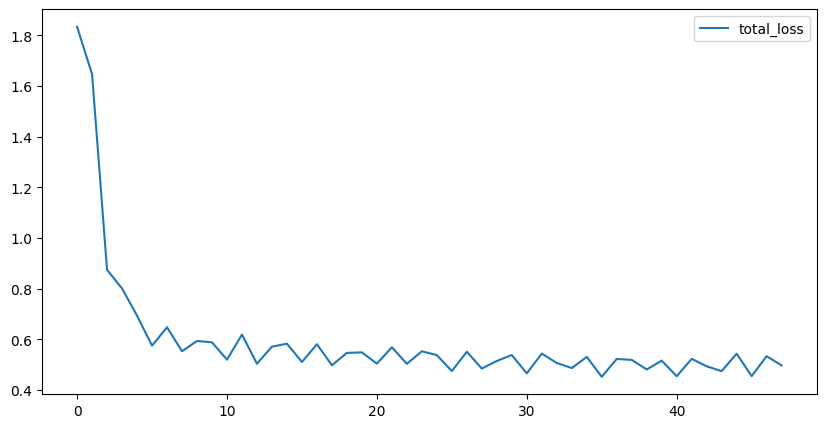

In [2]:
from matplotlib import pyplot as plt
import json

with open("/mnt/shared-storage-user/llmit/user/liuhongwei/rl_llmit/xtuner_train/verifier-interns1-lora-cold-011316/train_log.txt", "r")as f:
    train_data = []
    for line in f:
        if line.startswith("{'loss':"):
            data_item = json.loads(line.replace("'", '"').strip())
            train_data.append(data_item)

loss = [data_item["loss"] for data_item in train_data]
norm = [data_item["grad_norm"] for data_item in train_data]


plt.figure(figsize=(10, 5))
plt.plot(loss, label="total_loss")
plt.legend()
plt.show()

        

In [ ]:
new_data = []
with open("/mnt/shared-storage-user/llmit/user/liuhongwei/verifier_llmit/scripts/lora_cold_data/verifier_data_output/verifier_sft_train_data_final.jsonl", "r")as f:
    for line in f:
        data_item = json.loads(line)
        # new_data_item["extra_info"] = data_item
        new_data.append({"messages": data_item.pop("messages")})

with open("/mnt/shared-storage-user/llmit/user/liuhongwei/verifier_llmit/scripts/lora_cold_data/verifier_data_output/verifier_sft_train_data_final_pure.jsonl", "w")as f:
    for data in new_data:
        f.write(json.dumps(data, ensure_ascii=False) + "\n")






In [3]:
import torch
import torch.nn as nn

class VerifierModule(nn.Module):
    def __init__(self, d, x_h = 4, d_h = 2):
        super().__init__()
        
        self.d = d
        self.x_h = x_h
        self.d_h = d_h
        self.sub_d = d // x_h
        self.x_l = nn.Linear(self.d, self.x_h * self.sub_d)
        assert self.d % x_h == 0 and  x_h % d_h == 0
        self.y_l = nn.Linear(self.d, self.d_h * self.sub_d)
        self.z_l = nn.Linear(self.d, self.d_h * self.sub_d)
        self.o_l = nn.Linear(self.d, self.d)
        self.dp = nn.Dropout(0.1)

    def forward(self, x, mask = None, p_cache = None, use_kv_cache = False):
        self.bs, self.n, _ = x.shape

        x = self.x_l(x)
        y = self.y_l(x)
        z = self.z_l(x)
        print(x.shape, y.shape, z.shape)
        x = x.reshape(self.bs, self.n, self.x_h, self.sub_d).transpose(1, 2)
        y = y.reshape(self.bs, self.n, self.d_h, self.sub_d).transpose(1, 2)
        z = z.reshape(self.bs, self.n, self.d_h, self.sub_d).transpose(1, 2)
        print(x.shape, y.shape, z.shape)
        y = y.repeat_interleave(self.x_h // self.d_h, dim=1)
        z = z.repeat_interleave(self.x_h // self.d_h, dim=1)
        print(x.shape)
        print(z.shape)
        if p_cache is not None and use_kv_cache: 
            p_cache[0] = torch.cat([p_cache[0], y], dim=0)
            p_cache[1] = torch.cat([p_cache[1], z], dim=0)
            y = p_cache[0]
            z = p_cache[1]
        casual_mask = torch.triu(torch.full((self.sub_d, self.sub_d), float('-inf')), diagonal=1)
        print(casual_mask)
        score = torch.softmax(torch.matmul(y, z.transpose(2, 3)) * torch.rsqrt(torch.tensor(self.d // self.x_h)) + casual_mask, dim=-1)
        print(score.shape)
        score = score.transpose(1, 2).reshape(self.bs, self.n, self.d)
        o = self.o_l(score)
        o = self.dp(o)
        return o


module = VerifierModule(32)
out = module(torch.randn(4, 8, 32))

print(out)


torch.Size([4, 8, 32]) torch.Size([4, 8, 16]) torch.Size([4, 8, 16])
torch.Size([4, 4, 8, 8]) torch.Size([4, 2, 8, 8]) torch.Size([4, 2, 8, 8])
torch.Size([4, 4, 8, 8])
torch.Size([4, 4, 8, 8])
tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])
torch.Size([4, 4, 8, 8])
tensor([[[-0.2359,  0.2576, -0.0556,  ..., -0.0910,  0.2258,  0.1813],
         [-0.1826,  0.0000,  0.1570,  ..., -0.1420,  0.1357,  0.0966],
         [-0.3371,  0.0075,  0.2172,  ..., -0.1183,  0.0866,  0.0368],
         ...,
         [-0.2588, -0.0470,  0.1697,  ..., -0.1580,  0.2386,  0.2040],
         [-0.3180,  0.0154,  0.1084,  ..., -0.0879,  0.2852,  0.2445],
         [-0.2896, 

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer


def get_log_probs(inputs, model, tokenizer):
    with torch.no_grad():
        input_ids = tokenizer(inputs, return_tensors="pt").to(device)
        logprobs = torch.log_softmax(model(input_ids).logits, dim=-1)
        return logprobs

def caculate_dpo_loss(model, ref_model, input_datas, tokenizer, beta=0.1):
    for input_data_batch in input_datas:
        input_x = input_data_batch["input"]
        input_y_accept = input_data_batch["output_accept"]
        input_y_reject = input_data_batch["output_reject"]

        input_accepts = input_x + input_y_accept
        input_rejects = input_x + input_y_reject
        inputs = torch.cat([input_accepts, input_rejects], dim=0)

        policy_log_probs = get_log_probs(inputs, model, tokenizer)
        policy_log_probs_accept = policy_log_probs[:len(input_accepts)]
        policy_log_probs_reject = policy_log_probs[len(input_accepts):]

        ref_log_probs = get_log_probs(inputs, ref_model, tokenizer)
        ref_log_probs_accept = ref_log_probs[:len(input_accepts)]
        ref_log_probs_reject = ref_log_probs[len(input_accepts):]

        ratios_accept = policy_log_probs_accept - ref_log_probs_accept
        ratios_reject = policy_log_probs_reject - ref_log_probs_reject

        loss = -torch.mean(torch.log(torch.sigmoid(beta * (ratios_accept - ratios_reject))))
        print(loss)

model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3-8B-Instruct")
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Meta-Llama-3-8B-Instruct")















In [1]:
import json, random, math
from pathlib import Path

# 路径
path = Path('/mnt/shared-storage-user/liuhongwei/main_works/cache/0.jsonl')
if not path.exists():
    print('file not found')
    raise SystemExit

# 读样本，优先取 key: output/outputs/response
samples = []
with path.open('r', encoding='utf-8') as f:
    for line in f:
        try:
            obj = json.loads(line)
            out = obj.get('output') or obj.get('outputs') or obj.get('response')
            if out:
                samples.append(out)
        except Exception:
            continue

# 取 100 条
random.seed(42)
if len(samples) > 100:
    samples = random.sample(samples, 100)

# 停用符集合
current_stops = ["</think>", "<｜end of thought｜>", "\n\n", ".\n\n"]
new_stops = [".\n", "?\n", "</think>", "<｜end of thought｜>", "\n\n", ".\n\n"]

def char_to_token_index(text, pos):
    tokens = text.split()
    cum = 0
    for idx, tok in enumerate(tokens):
        cum += len(tok)
        if cum >= pos:
            return idx + 1
        cum += 1  # space
    return len(tokens)

def steps_with_stop_interval(text, stop_list, interval):
    tokens = text.split()
    tok_len = len(tokens)
    if tok_len == 0:
        return 1, 0
    stop_pos = None
    for s in stop_list:
        p = text.find(s)
        if p != -1:
            if stop_pos is None or p < stop_pos:
                stop_pos = p
    if stop_pos is not None:
        eff_tokens = char_to_token_index(text, stop_pos)
    else:
        eff_tokens = tok_len
    steps = max(1, math.ceil(eff_tokens / interval))
    return steps, eff_tokens

stats = {
    'count': len(samples),
    'current_stop+interval': [],
    'new_stop+interval': [],
    'interval_only': [],
}
for txt in samples:
    tok_len = len(txt.split()) or 1
    stats['interval_only'].append(math.ceil(tok_len/2048))
    s_cur, eff_cur = steps_with_stop_interval(txt, current_stops, 2048)
    stats['current_stop+interval'].append(s_cur)
    s_new, eff_new = steps_with_stop_interval(txt, new_stops, 2048)
    stats['new_stop+interval'].append(s_new)

for key, arr in stats.items():
    if key == 'count':
        continue
    print(f"{key}: n={len(arr)}, avg={sum(arr)/len(arr):.3f}, min={min(arr)}, max={max(arr)}")

current_stop+interval: n=100, avg=1.000, min=1, max=1
new_stop+interval: n=100, avg=1.000, min=1, max=1
interval_only: n=100, avg=4.630, min=1, max=12
